In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. 載入原始資料
df = pd.read_csv('YRBS_2007.csv')

# 2. 定義這次專案所有會用到的核心欄位 (加入了性別 WhatIsYourSex)
cols_needed = [
    'HowTallAreYouWithoutShoesInMeters', 
    'HowMuchDoYouWeighWithoutShoesInKG', 
    'PhysicalFightingAtSchool',
    'WhatIsYourSex'
]

# 3. 確保這四個欄位都沒有空值，並複製一份乾淨的資料表
df_clean = df.dropna(subset=cols_needed).copy()

# 4. 直接計算連續變數 BMI
df_clean['BMI'] = df_clean['HowMuchDoYouWeighWithoutShoesInKG'] / (df_clean['HowTallAreYouWithoutShoesInMeters'] ** 2)

# 5. 快速檢查清理後的身高、體重與資料筆數
print("清理後的資料總筆數：", len(df_clean))
print(df_clean[['BMI', 'WhatIsYourSex', 'PhysicalFightingAtSchool']].head())

清理後的資料總筆數： 12820
         BMI  WhatIsYourSex  PhysicalFightingAtSchool
3  29.876924            1.0                       1.0
5  19.853654            1.0                       1.0
6  20.758111            1.0                       1.0
7  22.148437            1.0                       1.0
8  18.402369            1.0                       1.0


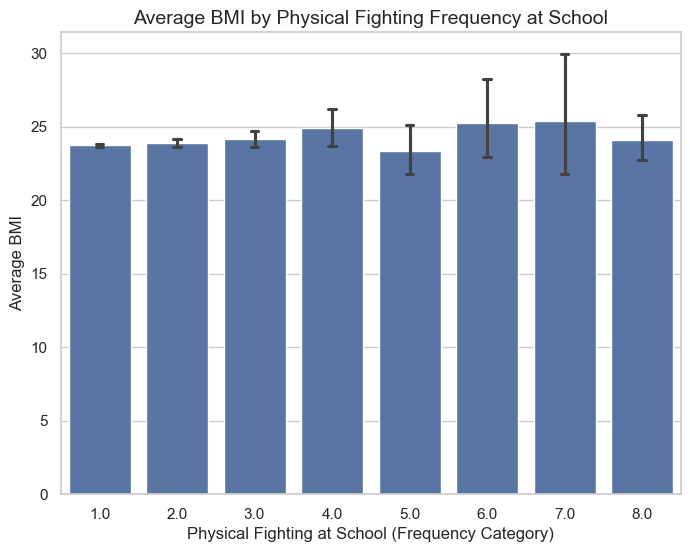

In [9]:
# 設定繪圖風格
sns.set_theme(style="whitegrid")

# 繪製不同打架頻率與平均 BMI 的關係圖 (X與Y對調)
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    x='PhysicalFightingAtSchool', 
    y='BMI', 
    data=df_clean,
    capsize=0.1
)

plt.title('Average BMI by Physical Fighting Frequency at School', fontsize=14)
plt.xlabel('Physical Fighting at School (Frequency Category)', fontsize=12)
plt.ylabel('Average BMI', fontsize=12)

# 顯示圖表
plt.show()

In [11]:
import scipy.stats as stats

# 由於你的 X 軸 (打架頻率) 有 1 到 7 個不同的級距
# 我們需要把這 7 個組別的 BMI 數值分別取出來放進一個列表中
groups = []
# 找出所有不重複的打架頻率級距 (1.0, 2.0, 3.0...) 並排序
categories = sorted(df_clean['PhysicalFightingAtSchool'].dropna().unique())

for category in categories:
    # 篩選出該級距的學生，並取出他們的 BMI 數值，排除空值
    bmi_values = df_clean[df_clean['PhysicalFightingAtSchool'] == category]['BMI'].dropna()
    groups.append(bmi_values)

# 將這 7 組資料放入 ANOVA 模型中進行檢定 (*groups 會自動把列表解包成獨立的參數)
f_statistic, p_value = stats.f_oneway(*groups)

print("=== 新版 ANOVA 檢定結果 ===")
print(f"研究問題：參與不同校園打架頻率的學生，其平均 BMI 是否有顯著差異？")
print("-" * 30)
print(f"F-statistic (F值): {f_statistic:.4f}")
print(f"P-value (P值): {p_value:.4e}")
print("-" * 30)

# 自動判讀結果
alpha = 0.05
if p_value < alpha:
    print("結論: P-value 小於 0.05，拒絕虛無假說。")
    print("這代表「不同校園打架頻率的學生，平均 BMI 確實有顯著差異」！你的研究假設成立。")
else:
    print("結論: P-value 大於或等於 0.05，無法拒絕虛無假說。")
    print("這代表「不管打架頻率多少，學生的平均 BMI 在統計上沒有顯著差異」。")

=== 新版 ANOVA 檢定結果 ===
研究問題：參與不同校園打架頻率的學生，其平均 BMI 是否有顯著差異？
------------------------------
F-statistic (F值): 1.4211
P-value (P值): 1.9168e-01
------------------------------
結論: P-value 大於或等於 0.05，無法拒絕虛無假說。
這代表「不管打架頻率多少，學生的平均 BMI 在統計上沒有顯著差異」。


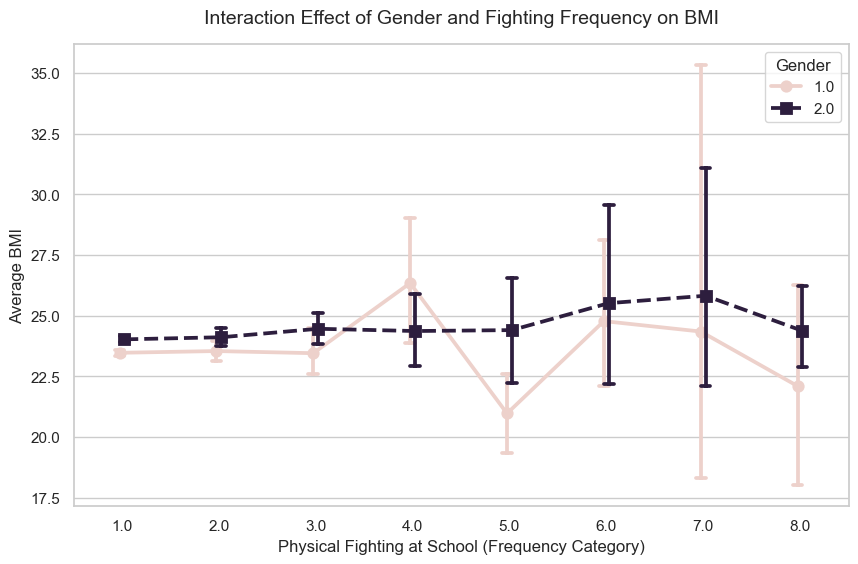

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1. 載入需要的欄位 (這次加入了 WhatIsYourSex)
cols_needed_2way = [
    'HowTallAreYouWithoutShoesInMeters', 
    'HowMuchDoYouWeighWithoutShoesInKG', 
    'PhysicalFightingAtSchool',
    'WhatIsYourSex'  # 新增性別欄位
]

# 排除包含空值的資料
df_clean_2way = df.dropna(subset=cols_needed_2way).copy()

# 計算 BMI
df_clean_2way['BMI'] = df_clean_2way['HowMuchDoYouWeighWithoutShoesInKG'] / (df_clean_2way['HowTallAreYouWithoutShoesInMeters'] ** 2)

# 2. 資料視覺化：繪製雙變數趨勢折線圖 (Pointplot)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 使用 pointplot 畫出兩條折線 (hue='WhatIsYourSex' 會自動分開男女)
ax = sns.pointplot(
    x='PhysicalFightingAtSchool', 
    y='BMI', 
    hue='WhatIsYourSex', 
    data=df_clean_2way,
    capsize=0.1,         # 誤差線的橫槓
    markers=["o", "s"],  # 兩種不同性別的點標記 (圓形與方形)
    linestyles=["-", "--"], # 兩種不同性別的線條樣式 (實線與虛線)
    dodge=True           # 讓兩條線的點稍微錯開，避免重疊看不清楚
)

plt.title('Interaction Effect of Gender and Fighting Frequency on BMI', fontsize=14, pad=15)
plt.xlabel('Physical Fighting at School (Frequency Category)', fontsize=12)
plt.ylabel('Average BMI', fontsize=12)
plt.legend(title='Gender')

# 顯示圖表
plt.show()

In [15]:
# 3. 執行雙因子變異數分析 (Two-Way ANOVA)
formula = 'BMI ~ C(PhysicalFightingAtSchool) + C(WhatIsYourSex) + C(PhysicalFightingAtSchool):C(WhatIsYourSex)'
model = ols(formula, data=df_clean_2way).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# --- 新增這行：設定 Pandas 不要使用科學記號，統一保留到小數點後 4 位 ---
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("=== 雙因子變異數分析 (Two-Way ANOVA) 結果 ===")
print(anova_table)

=== 雙因子變異數分析 (Two-Way ANOVA) 結果 ===
                                                  sum_sq         df       F  \
C(PhysicalFightingAtSchool)                     173.8339     7.0000  1.0061   
C(WhatIsYourSex)                               1018.5029     1.0000 41.2624   
C(PhysicalFightingAtSchool):C(WhatIsYourSex)    176.0609     7.0000  1.0190   
Residual                                     316048.4449 12804.0000     NaN   

                                              PR(>F)  
C(PhysicalFightingAtSchool)                   0.4245  
C(WhatIsYourSex)                              0.0000  
C(PhysicalFightingAtSchool):C(WhatIsYourSex)  0.4153  
Residual                                         NaN  
